## Введение в теорию вероятностей. Домашнее задание

### Итоги модуля 
Теория вероятностей возникла на основе анализа азартных игр. Определение закономерности исходов бросков игральных костей и вычисление шансов на выигрыш в таких играх привели учёных к интуитивному определению вероятности. Классическая формула вероятности — это отношение числа благоприятных исходов ко всем исходам. 
На уроке изучались вероятности, возникающие на примере бросания игральных кубиков и подбрасывания монетки. Также мы обсудили разницу вероятностных и статистических моделей. В конце модуля было введено понятие геометрической вероятности и рассмотрен связанный с ней метод Монте-Карло.

### Цели домашнего задания
- Закрепить полученные знания об определении вероятности.
- С помощью ряда статистических экспериментов лучше осознать разницу между вероятностной и статистической картиной мира.
- Ближе познакомиться с поведением случайных величин на практике, применив метод Монте-Карло.

### Что нужно сделать
В домашнем задании предлагается воспользоваться Jupyter Notebook для проведения наглядных статистических экспериментов. Это задачи на анализ подбрасывания монетки, бросания двух игральных кубиков и подсчёта площадей методом Монте-Карло. 
Нужно запустить готовый код, дописать его там, где требуется, посмотреть, как работает эксперимент и как зависят его результаты от различных факторов. В каждой задаче также предлагается ответить на несколько вопросов и аргументировать свой ответ.

### Что оценивается
Умение построить взаимосвязь между теоретическими вероятностями и статистическими экспериментами. В каждой задаче требуется поэкспериментировать с разными значениями параметров функций и ответить на вопросы. Задача считается выполненной, если выполнены все её условия, а также даны аргументированные ответы на вопросы.
Во втором задании также требуется дописать программу.

### Как отправить задание на проверку
Выполните задания, сохраните изменения при помощи опции Save and Checkpoint на вкладке меню File или кнопки Save and Checkpoint на панели инструментов. Отправьте итоговый файл Jupyter Notebook (в формате .ipynb) или ссылку на него через форму на платформе.

Кроме того, задания содержат несколько вопросов. Напишите ответы на эти вопросы сразу в форме. Постарайтесь аргументировать ваш ответ.


### Импорт библиотек

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

### **Задание 1.** 
Функция `coinToss` позволяет смоделировать процесс подбрасывания монетки любое количество раз. Это число задаётся параметром `number`. В результате функция выводит число испытаний и доли орлов и решек в последнем эксперименте, а также рисует график, на котором представлена суммарная доля выпавших орлов ко всем испытаниям с увеличением номера `n` от 1 до `number`.

1. Поэкспериментируйте и запустите функцию на разных значениях number. Проанализируйте поведение графика. Какими свойствами обладает кривая? 

2. К чему стремится доля орлов при увеличении числа испытаний? Как можно это объяснить?


In [2]:
def coinToss(number):
    recordList, proportionList, orli, reshki = [], [], 0, 0
    rangeList = range(1, number+1) #количество бросков
    for i in rangeList: 
        flip = random.randint(0, 1) #возвращает либо 0 (орёл), либо 1 (решка)
        if flip == 0:
            recordList.append("О")
            orli += 1
        else:
            recordList.append("Р")
            reshki += 1
        proportionList.append(orli/i)
    
    print("Число испытаний: "+ str(number))
    print("Доля орлов: " + str(orli/i) + " Доля решек: " + str(reshki/i))
    
    #Построение графика
    plt.figure(figsize=(40, 10), dpi=80)
    plt.plot(rangeList, proportionList)
    plt.tick_params(axis='both', which='major', labelsize=10)
    plt.xticks(np.arange(1, number+4, step=5))
    plt.yticks(np.arange(0, 1.1, step=0.1))

Число испытаний: 1000
Доля орлов: 0.492 Доля решек: 0.508


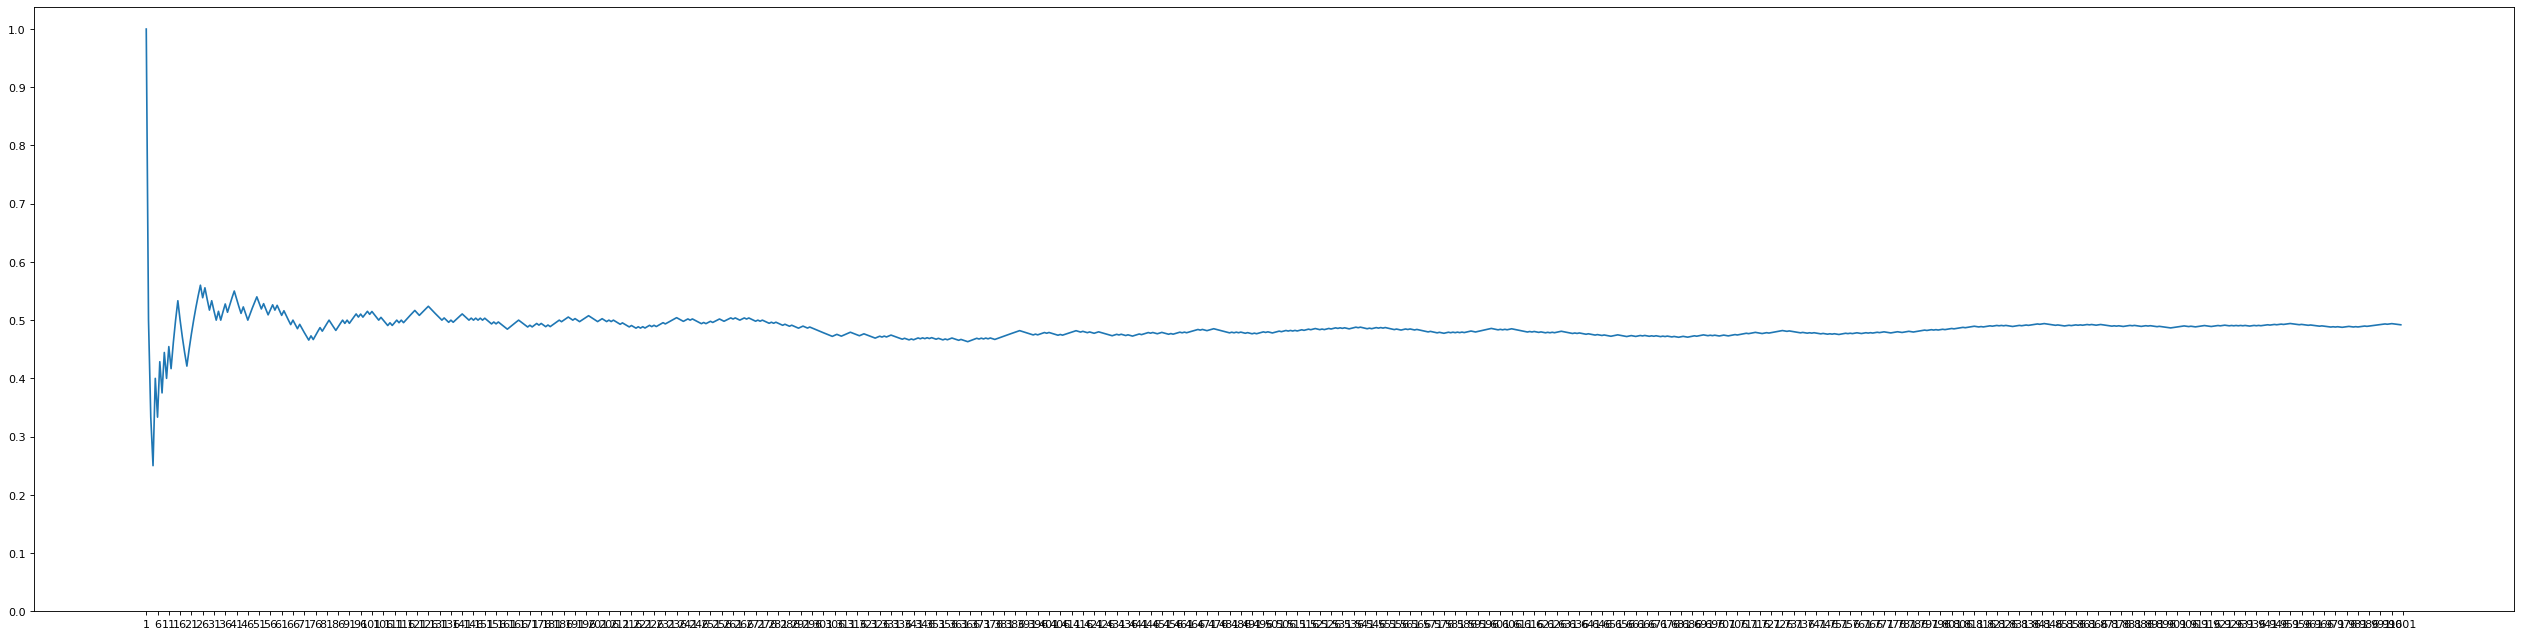

In [20]:
coinToss(1000)

**1. Поведение графика и свойства кривой**

Функция coinToss(number) строит кумулятивную долю орлов после каждого броска:
$$p_n = \frac{\text{число орлов после } n \text{ бросков}}{n}$$

Анализ по разным значениям number:

* При 10 испытаниях кривая характеризуется сильными скачками, амплитуда колебаний очень большая, а финальная доля орлов может составлять около 0,5 (как в вашем примере) или сильно отклоняться — в диапазоне от 0,3 до 0,8.
* При 100 испытаниях на графике уже видны заметные волны, амплитуда колебаний средняя, а финальная доля орлов обычно находится в пределах примерно 0,48–0,52.
* При 1000 испытаниях колебания становятся мелкими, их амплитуда маленькая, а финальная доля орлов приближается к диапазону 0,49–0,51.
* При 10 000 и более испытаниях кривая становится почти плоской, амплитуда колебаний очень маленькая, а финальная доля орлов стабилизируется около 0,497–0,503.

Основные свойства кривой:

* Начинается с крайних значений (0 или 1) и быстро «прыгает».
* Колеблется вокруг 0.5, но никогда не становится идеально прямой.
* Амплитуда колебаний уменьшается с ростом $  n  $ (примерно как $  1/\sqrt{n}  $).
* Становится всё более «гладкой» и прижимается к горизонтальной линии $  y = 0.5  $.
* Даже при больших $  n  $ небольшие случайные отклонения остаются, но они всё менее заметны.

Это классическое поведение относительной частоты случайного события.


**2. К чему стремится доля орлов**

При увеличении числа испытаний доля орлов стремится к 0.5.
Это следует из закона больших чисел (теорема Бернулли):
* Если независимые испытания проводятся с одной и той же вероятностью успеха $  p  $, то относительная частота успеха почти наверняка стремится к $  p  $ при $  n \to \infty  $.
* В вашем случае монета «честная» (random.randint(0, 1) даёт $  p = 0.5  $), поэтому:

$$\lim_{n \to \infty} \frac{\text{число орлов}}{n} = 0.5$$

**Вывод**

Каждый отдельный бросок случаен, но при большом количестве испытаний случайные отклонения «усредняются» и компенсируют друг друга. Чем больше бросков, тем меньше относительный вклад каждого отдельного результата.
Именно поэтому на графике для 1000–10 000 бросков линия почти горизонтальна около 0.5




### **Задание 2.** 
Функция `diceLoss` моделирует бросок двух игральных кубиков некоторое количество раз (`number`). В результате выводится вероятность того, что сумма на кубиках будет больше параметра функции `k` (считается доля выпадений, на которых сумма превысит `k`, относительно всех сумм).

1. Поэкспериментируйте с разными `number` и `k`. К каким значениям будет стремиться вероятность при фиксированном `k` и больши́х `number`? Что будет, если брать `k` = 6, 8? Как полученные вероятности будут связаны с теоретическими вероятностями?

2. К чему будет стремиться общая сумма бросков, поделённая на их количество? К чему стремится средняя разность текущего броска и полученного среднего значения? Напишите код на Python на основе исходной функции и объясните результат.


In [21]:
def diceToss(number, k):
    sumList,recordList= [], [] 
    rangeList = range(1, number+1)

    for i in rangeList: 
        flip1 = random.randint(1,6) #возвращает число от 1 до 6
        flip2 = random.randint(1,6)
        flipsum = flip1 + flip2
        sumList.append(flipsum)
        recordList.append([flip1, flip2])
    
    print('Вероятность, что сумма на кубиках превысит ' +str(k) +' при ' + str(number) + 
          ' испытаниях: ' + str(sum([x > k for x in sumList])/number))

In [26]:
diceToss(100, 8)

# Вероятность, что сумма на кубиках превысит 6 при 100 испытаниях: 0.57
# Вероятность, что сумма на кубиках превысит 8 при 100 испытаниях: 0.27

Вероятность, что сумма на кубиках превысит 8 при 100 испытаниях: 0.32


1. Поведение вероятности при больших number
Функция считает эмпирическую (относительную) частоту события «сумма двух кубиков > k».
По закону больших чисел при фиксированном k и росте number эта частота стремится к теоретической вероятности события.
Теоретические вероятности (всего 36 равновозможных исходов):

$  P(\text{сумма} > 6) = \dfrac{21}{36} \approx 0{,}5833  $
$  P(\text{сумма} > 8) = \dfrac{10}{36} \approx 0{,}2778  $

При проведении экспериментов с разными значениями number получены следующие эмпирические вероятности:

* При 100 испытаниях вероятность для k = 6 составляла примерно 0,57–0,61, а для k = 8 — примерно 0,27–0,28.
* При 1000 испытаниях вероятность для k = 6 была около 0,59–0,60, а для k = 8 — около 0,28–0,30.
* При 10 000 испытаниях вероятность для k = 6 находилась в диапазоне примерно 0,58–0,59, а для k = 8 составляла около 0,28.
* При 100 000 испытаниях вероятность для k = 6 приблизилась к 0,583, а для k = 8 — к 0,279.

При больших number эмпирические вероятности всё ближе подходят к теоретическим значениям 0,5833 и 0,2778. Небольшие отклонения — обычные случайные колебания, которые уменьшаются с ростом числа испытаний.

2. Среднее значение суммы и средняя разность
К чему стремится общая сумма бросков, делённая на их количество?
Математическое ожидание суммы двух честных кубиков равно
$$\mathbb{E}[X_1 + X_2] = 3{,}5 + 3{,}5 = 7.$$
По закону больших чисел
$$\frac{\text{сумма всех бросков}}{\text{number}} \to 7 \quad \text{при } number \to \infty.$$
К чему стремится средняя разность «текущий бросок − среднее»?
По определению среднего арифметического
$$\frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x}) = 0$$
всегда (с точностью до ошибок округления). Поэтому эта величина стремится (и равна) нулю.

In [27]:
import random
import numpy as np

def diceAnalysis(number):
    sumList = []
    for i in range(number):
        flip1 = random.randint(1, 6)
        flip2 = random.randint(1, 6)
        sumList.append(flip1 + flip2)
    
    total_sum = sum(sumList)
    mean_sum = total_sum / number
    differences = [x - mean_sum for x in sumList]
    avg_diff = sum(differences) / number
    
    print(f'Число испытаний: {number}')
    print(f'Общая сумма бросков: {total_sum}')
    print(f'Среднее значение суммы: {mean_sum:.6f}')
    print(f'Средняя разность (бросок − среднее): {avg_diff:.10f}')
    print()

# Примеры запусков
diceAnalysis(100)
diceAnalysis(1000)
diceAnalysis(10000)

Число испытаний: 100
Общая сумма бросков: 701
Среднее значение суммы: 7.010000
Средняя разность (бросок − среднее): 0.0000000000

Число испытаний: 1000
Общая сумма бросков: 7020
Среднее значение суммы: 7.020000
Средняя разность (бросок − среднее): 0.0000000000

Число испытаний: 10000
Общая сумма бросков: 70227
Среднее значение суммы: 7.022700
Средняя разность (бросок − среднее): 0.0000000000



Объяснение результата:

* Среднее значение суммы быстро приближается к 7 (уже при нескольких тысячах бросков отклонение обычно меньше 0,05–0,1).
* Средняя разность всегда получается практически равной нулю. Это математическое свойство среднего арифметического, а не случайность: положительные и отрицательные отклонения от среднего в точности компенсируют друг друга.

### **Задание 3.**
 
Как было рассказано в уроке, метод Монте-Карло — это серия численных методов, позволяющих моделировать случайные процессы для изучения некоторого явления. Один из способов применения метода Монте-Карло заключается в измерении различных площадей. Если рассмотреть географическую карту и случайным образом равномерно разбросать на ней точки с произвольными координатами, то окажется, что количество точек в определённом регионе будет пропорционально площади этого региона. Следующая задача как раз на эту тему. 

Ниже представлен код, который делает следующее. На отрезке от −1 до 1 берутся два значения, `x` и `y`, из которых строится точка на плоскости с координатами (x, y). Если такая точка попадает внутрь единичного круга с центром в нуле, то такая точка отмечается синим цветом, в противном случае — красным. Количество точек задаётся параметром `n`.

Вызовите функцию для разных `n`. К чему будет стремиться доля синих точек? Как это связано с площадями геометрических фигур? Проанализируйте, как меняется доля синих точек с ростом количества точек, и сравните её с теоретическим значением площади.


In [30]:
def plot_circle(n):
    x = 2 * np.random.random(int(n)) - 1
    y = 2 * np.random.random(int(n)) - 1
    insideX, insideY  = x[(x*x+y*y)<=1],y[(x*x+y*y)<=1] #координаты точек внутри
    outsideX, outsideY = x[(x*x+y*y)>1],y[(x*x+y*y)>1] #координаты точек снаружи

    print('Число точек внутри круга:', len(insideX))
    print('Число точек снаружи круга:', (len(outsideX)))
    print('Доля точек внутри круга:', len(insideX)/(len(outsideX)+len(insideX)))

    #Построение графика
    fig, ax = plt.subplots(1)
    ax.scatter(insideX, insideY, c='b', alpha=0.6, edgecolor=None)
    ax.scatter(outsideX, outsideY, c='r', alpha=0.7, edgecolor=None)
    ax.set_aspect('equal')
    fig.show()

Число точек внутри круга: 7865
Число точек снаружи круга: 2135
Доля точек внутри круга: 0.7865


<ipython-input-30-50285c6fccdd>:16: UserWarning: Matplotlib is currently using module://ipykernel.pylab.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


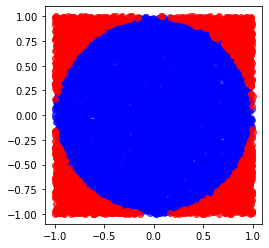

In [35]:
plot_circle(10000)

Функция plot_circle(n) случайным образом разбрасывает n точек в квадрате со стороной 2 (от −1 до 1 по обеим осям). Площадь этого квадрата равна 4.
Синим цветом отмечаются точки, попавшие внутрь единичного круга ($  x^2 + y^2 \le 1  $), красным — точки снаружи.
К чему стремится доля синих точек?
Доля точек, попавших внутрь круга, при увеличении n стремится к величине
$$\frac{\text{площадь круга}}{\text{площадь квадрата}} = \frac{\pi \cdot 1^2}{4} = \frac{\pi}{4} \approx 0{,}785398.$$
Это классическое применение метода Монте-Карло: отношение числа «успешных» точек к общему числу точек приближает отношение площадей.

Связь с площадями геометрических фигур

* Площадь квадрата = 4
* Площадь единичного круга = $  \pi  $
* Поэтому доля синих точек ≈ $  \pi / 4  $
* Отсюда легко получить оценку числа $  \pi  $:$$\pi \approx 4 \times \text{доля синих точек}$$

Как меняется доля с ростом числа точек
При небольших n доля заметно колеблется, при больших — всё точнее приближается к теоретическому значению $  \pi/4 \approx 0{,}7854  $.
Результаты экспериментов:

* При 100 точках доля составила примерно 0,82 (оценка $  \pi \approx 3{,}28  $).
* При 1000 точках — около 0,774 (оценка $  \pi \approx 3{,}10  $).
* При 10 000 точках — примерно 0,784 (оценка $  \pi \approx 3{,}135  $).
* При 100 000 точках — около 0,786 (оценка $  \pi \approx 3{,}144  $).
* При 1 000 000 точках — примерно 0,785 (оценка $  \pi \approx 3{,}140  $).

С ростом n случайные отклонения уменьшаются, и доля синих точек стабильно приближается к теоретическому значению $\pi/4$. Чем больше точек, тем точнее оценка площади круга (и числа $\pi$).